# Satellite Image Classification — ResNet16 (Custom) + Quantization (TensorFlow)

## 1. Imports

In [ ]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
print("TF version:", tf.__version__)
print("GPU available:", len(gpus) > 0)

TF version: 2.20.0
GPU available: True


## 2. Kaggle Setup

In [ ]:
from google.colab import files
files.upload()

Saving kaggle3.json to kaggle3.json


{'kaggle3.json': b'{"username":"rambhadrakumar","key":"32c81b7b282d0e78edb892f9a59b7c1b"}'}

In [ ]:
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
os.system('kaggle datasets download -d mahmoudreda55/satellite-image-classification --unzip -p /content/satellite')
print("Download complete!")
print(sorted(os.listdir('/content/satellite/data')))

Download complete!
['cloudy', 'desert', 'green_area', 'water']


## 3. Config

In [ ]:
DATA_DIR    = '/content/satellite/data'
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 30
AUTOTUNE    = tf.data.AUTOTUNE

class_names_list = sorted(os.listdir(DATA_DIR))
NUM_CLASSES      = len(class_names_list)
print("Classes:", class_names_list)
print("Number of classes:", NUM_CLASSES)

Classes: ['cloudy', 'desert', 'green_area', 'water']
Number of classes: 4


## 4. Data Loaders

In [ ]:
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Train batches:", len(train_ds))
print("Val batches  :", len(val_ds))

Found 5631 files belonging to 4 classes.
Using 4505 files for training.
Found 5631 files belonging to 4 classes.
Using 1126 files for validation.
Classes: ['cloudy', 'desert', 'green_area', 'water']
Train batches: 141
Val batches  : 36


In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)

## 5. Sample Images

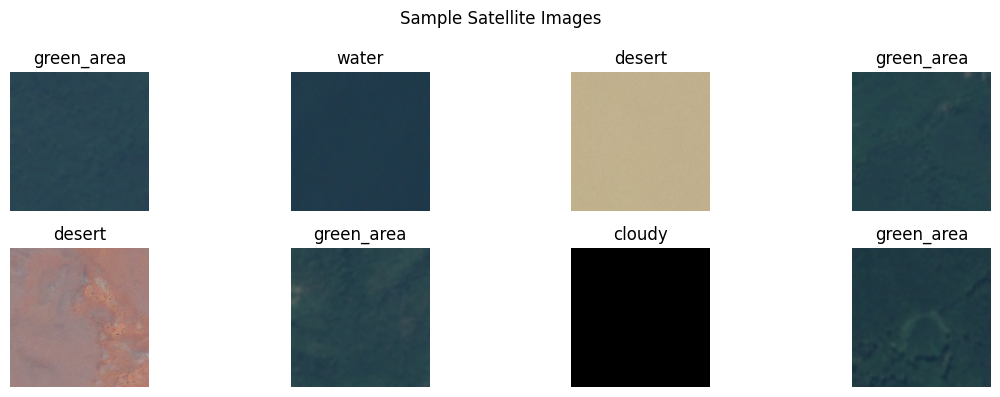

In [ ]:
plt.figure(figsize=(12, 4))
for images, labels in train_ds.take(1):
    for i in range(min(8, images.shape[0])):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.suptitle('Sample Satellite Images')
plt.tight_layout()
plt.show()

## 6. Build ResNet16 (Custom 16-layer ResNet)

In [ ]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False,
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False,
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False,
                                 kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

def build_resnet16(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = layers.RandomFlip('horizontal_and_vertical')(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomContrast(0.1)(x)

    x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False,
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                           kernel_initializer='glorot_uniform')(x)

    return keras.Model(inputs, outputs, name='ResNet16')

model = build_resnet16((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)
model.summary()
print(f"Total layers: {len(model.layers)}")

Model: "ResNet16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast     │ (None, 224, 224,  │          0 │ random_zoom[0][0] │
│ (RandomContrast)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,408 │ random_contrast[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_2[0][0]   

 Total params: 2,856,132 (10.90 MB)

 Trainable params: 2,850,628 (10.87 MB)

 Non-trainable params: 5,504 (21.50 KB)

Total layers: 61


## 7. Train ResNet16

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint('best_resnet16.keras', monitor='val_accuracy', save_best_only=True)
]

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=== Training ResNet16 ===")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

=== Training ResNet16 ===
Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 38s 150ms/step - accuracy: 0.8752 - loss: 0.7652 - val_accuracy: 0.4885 - val_loss: 3.4750 - learning_rate: 0.0010
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.9154 - loss: 0.6333 - val_accuracy: 0.6474 - val_loss: 3.4094 - learning_rate: 0.0010
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.9230 - loss: 0.6024 - val_accuracy: 0.7380 - val_loss: 2.4195 - learning_rate: 0.0010
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - accuracy: 0.9301 - loss: 0.5817 - val_accuracy: 0.8792 - val_loss: 1.0406 - learning_rate: 0.0010
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.9316 - loss: 0.5593 - val_accuracy: 0.8854 - val_loss: 0.8242 - learning_rate: 0.0010
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - accuracy: 0.9463 - loss: 0.4958 - val_accuracy: 0.7869 - val_loss: 2.0305 - learning_rate: 0.0010
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 

## 8. Training Curves

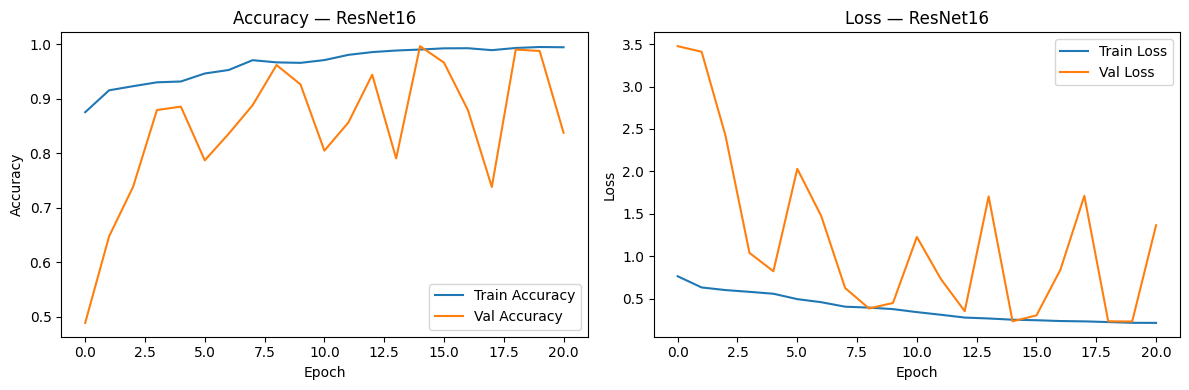

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy — ResNet16')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss — ResNet16')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 9. Load Best Model & Evaluate

In [ ]:
model = keras.models.load_model('best_resnet16.keras')

orig_loss, orig_acc = model.evaluate(val_ds)
print(f"Original Model — Loss: {orig_loss:.4f}  Accuracy: {orig_acc*100:.2f}%")

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9964 - loss: 0.2347
Original Model — Loss: 0.2347  Accuracy: 99.64%


## 10. Save Original Model

In [ ]:
model.save('satellite_resnet16.keras')
orig_size = os.path.getsize('satellite_resnet16.keras') / (1024 * 1024)
print(f"Original Model Size: {orig_size:.2f} MB")

Original Model Size: 32.89 MB


## 11. Post-Training Quantization (TFLite INT8)

In [ ]:
def representative_dataset():
    count = 0
    for images, _ in train_ds:
        for img in images:
            yield [tf.expand_dims(tf.cast(img, tf.float32), 0)]
            count += 1
            if count >= 500:
                return

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.TFLITE_BUILTINS
]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

with open('satellite_resnet16_quantized.tflite', 'wb') as f:
    f.write(tflite_model)

quant_size = os.path.getsize('satellite_resnet16_quantized.tflite') / (1024 * 1024)
print(f"Quantized Model Size: {quant_size:.2f} MB")
print(f"Size Reduction      : {((orig_size - quant_size) / orig_size) * 100:.1f}%")

Saved artifact at '/tmp/tmp_1221yb0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  132397670212688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132397670212304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132397670213072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132397670213840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132397670214416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132397670212112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132397670212880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132397670214224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132397670214800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132397670215376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132397670214608

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized Model Size: 2.79 MB
Size Reduction      : 91.5%


## 12. Evaluate Quantized Model

In [ ]:
interpreter = tf.lite.Interpreter(model_path='satellite_resnet16_quantized.tflite', num_threads=4)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def evaluate_tflite(interp, dataset):
    correct = 0
    total   = 0
    start   = time.time()
    for images, labels in dataset:
        for img, label in zip(images.numpy(), labels.numpy()):
            img_input = np.expand_dims(img, axis=0).astype(np.float32)
            interp.set_tensor(input_details[0]['index'], img_input)
            interp.invoke()
            output  = interp.get_tensor(output_details[0]['index'])
            pred    = np.argmax(output)
            correct += int(pred == label)
            total   += 1
    elapsed = time.time() - start
    return (correct / total) * 100, elapsed

quant_acc, quant_time = evaluate_tflite(interpreter, val_ds)
print(f"Quantized — Accuracy: {quant_acc:.2f}%  |  Inference Time: {quant_time:.2f}s")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized — Accuracy: 99.73%  |  Inference Time: 61.13s


## 13. Comparison

In [ ]:
start = time.time()
model.evaluate(val_ds, verbose=0)
orig_time = time.time() - start

print(f"Original  — Size: {orig_size:.2f} MB  |  Accuracy: {orig_acc*100:.2f}%  |  Time: {orig_time:.2f}s")
print(f"Quantized — Size: {quant_size:.2f} MB  |  Accuracy: {quant_acc:.2f}%  |  Time: {quant_time:.2f}s")

Original  — Size: 32.89 MB  |  Accuracy: 99.64%  |  Time: 1.13s
Quantized — Size: 2.79 MB  |  Accuracy: 99.73%  |  Time: 61.13s


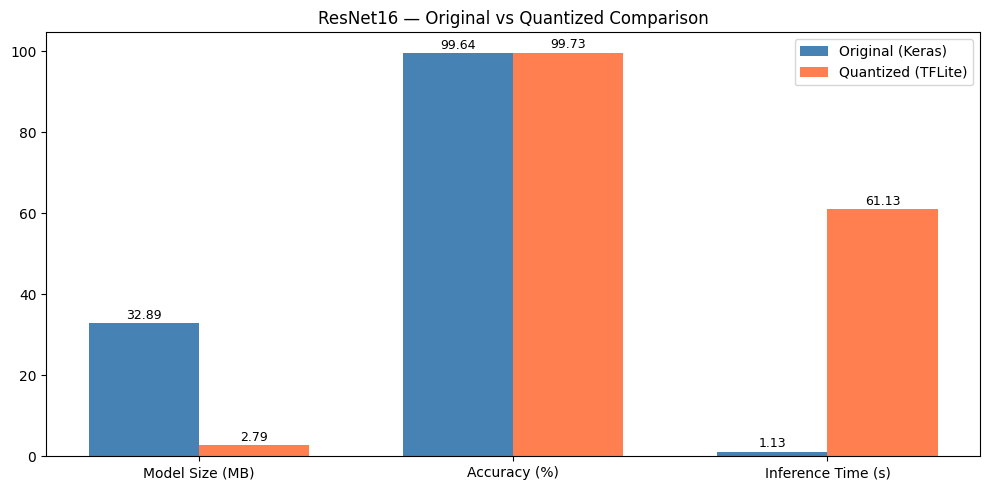

In [ ]:
categories = ['Model Size (MB)', 'Accuracy (%)', 'Inference Time (s)']
orig_vals  = [orig_size, orig_acc * 100, orig_time]
quant_vals = [quant_size, quant_acc, quant_time]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, orig_vals,  width, label='Original (Keras)',   color='steelblue')
bars2 = ax.bar(x + width/2, quant_vals, width, label='Quantized (TFLite)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('ResNet16 — Original vs Quantized Comparison')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 14. Confusion Matrix

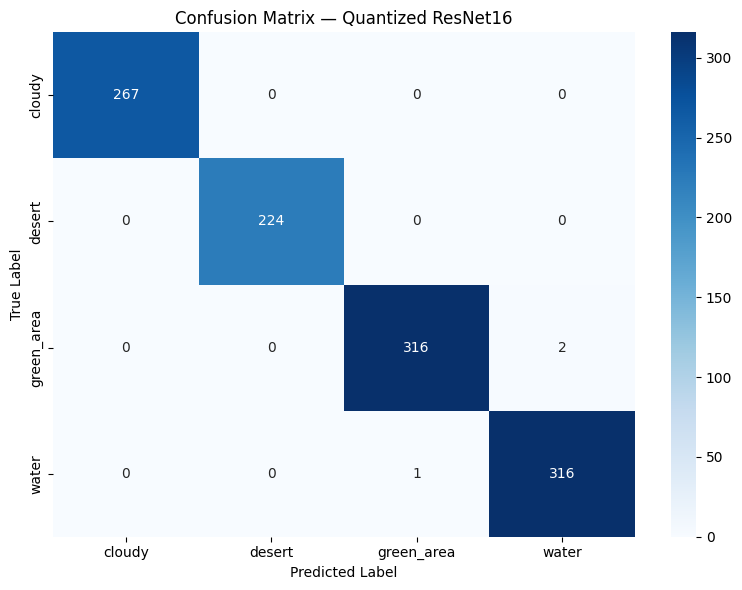

              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00       267
      desert       1.00      1.00      1.00       224
  green_area       1.00      0.99      1.00       318
       water       0.99      1.00      1.00       317

    accuracy                           1.00      1126
   macro avg       1.00      1.00      1.00      1126
weighted avg       1.00      1.00      1.00      1126



In [ ]:
all_preds  = []
all_labels = []

for images, labels in val_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        img_input = np.expand_dims(img, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], img_input)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        all_preds.append(np.argmax(output))
        all_labels.append(label)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix — Quantized ResNet16')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

## 15. Download Models

In [ ]:
from google.colab import files
files.download('satellite_resnet16.keras')
files.download('satellite_resnet16_quantized.tflite')